In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from typing import Sequence, Union, Optional
import matplotlib as mpl
import scipy.stats as stats
import importlib
import plsda_module
from scipy.stats import mannwhitneyu

In [21]:
plt.rcParams['xtick.labelsize'] = 18 # or whatever size you want
plt.rcParams['ytick.labelsize'] = 18 # or whatever size you want

# Set global font size for labels, titles and legends
plt.rcParams['axes.labelsize'] = 18# or whatever size you want
plt.rcParams['axes.titlesize'] = 18 # or whatever size you want
plt.rcParams['legend.fontsize'] = 18 # or whatever size you want
#plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.bottom'] = True


In [3]:
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42

mpl.rcParams['svg.fonttype'] = 'none'

In [ ]:
# # import calibrated model data
# model_data = pd.read_csv('/Volumes/FallahiLab/Maize-Data/Data/Yonatan_Degefu/AP1_mechanistic_modelling/calibrated_data_parameters_initial_conditions_allcells_filtered_081225.csv')

# # steady state data
# # should have the same number of rows as model_data but its not the case
# ss_file = "ap1_calibrated_matched_model_steadystates.csv"
# model_folder = "/Volumes/FallahiLab/Maize-Data/Data/Yonatan_Degefu/AP1_mechanistic_modelling/calibrated_data/"
# calibrated_steadystate = pd.read_csv(model_folder + ss_file)

In [14]:
import re

def rename_columns(df):
    new_column_names = {}
    
    def convert_protein_names(text):
        """Convert protein names - order is critical!"""
        # Do longer/more specific names first to avoid partial matches
        text = text.replace('jund', 'JUND')  # Do jund before jun
        text = text.replace('fra2', 'FRA2')  # Do fra2 before fra1
        text = text.replace('fra1', 'FRA1')
        text = text.replace('jun', 'cJUN')   # Do jun after jund
        text = text.replace('fos', 'cFOS')
        return text
    
    for col in df.columns:
        # For basal columns: replace with α (alpha) and add underscore
        if 'basal' in col:
            protein = re.search(r'basal_(\w+)', col).group(1)
            converted_protein = convert_protein_names(protein)
            new_column_names[col] = f"α_{converted_protein}"
        
        # For degradation columns: replace with γ (gamma) and add underscore
        elif 'degradation' in col:
            protein = re.search(r'degradation_(\w+)', col).group(1)
            converted_protein = convert_protein_names(protein)
            new_column_names[col] = f"γ_{converted_protein}"
        
        # For beta columns: replace with β (beta) and add underscore
        elif '.beta' in col:
            interaction = re.search(r'\((.*?)\)\.beta', col).group(1)
            converted_interaction = convert_protein_names(interaction)
            new_column_names[col] = f"β_{converted_interaction}"
        
        # Keep any other columns as is (like 'interest_class')
        else:
            new_column_names[col] = col
    
    return df.rename(columns=new_column_names)

# Apply the renaming to your existing subset_data
# clean_model_data = rename_columns(model_data.copy())
# clean_model_data.columns
# clean_model_data = clean_model_data.drop_duplicates(subset=['param_index','cell_line'])

In [19]:
importlib.reload(plsda_module)
from plsda_module import PLSDA

#### PLSDA analysis on un-calibrated data

In [3]:
ss_file = "20260316_full_non_calibrated_parameters_and_steady_states.csv"
model_folder = "/Volumes/FallahiLab/Maize-Data/Data/Yonatan_Degefu/AP1_mechanistic_modelling/"
non_calibrated_data = pd.read_csv(model_folder + ss_file)

In [4]:
non_calibrated_data

,param_index,init_cond_index,(basal_fos).v,(basal_jun).v,(basal_fra1).v,(basal_fra2).v,(basal_jund).v,(jun_by_junjun).beta,(jun_by_junfos).beta,(fra1_by_junfra1).beta,...,(degradation_jun).k1,(degradation_fra1).k1,(degradation_fra2).k1,(degradation_jund).k1,fos,jun,fra1,fra2,jund,state
0,0,100,0.439851,0.264344,0.322492,0.540968,0.173894,40.730958,3.145018,25.740128,...,0.665617,0.626845,0.136108,0.198823,0.7,0.5,0.6,9.2,1.0,"low, low, low, low, low"
1,0,70,0.439851,0.264344,0.322492,0.540968,0.173894,40.730958,3.145018,25.740128,...,0.665617,0.626845,0.136108,0.198823,0.7,0.5,0.6,9.2,1.0,"low, low, low, low, low"
2,0,69,0.439851,0.264344,0.322492,0.540968,0.173894,40.730958,3.145018,25.740128,...,0.665617,0.626845,0.136108,0.198823,0.7,0.5,0.6,9.2,1.0,"low, low, low, low, low"
3,0,68,0.439851,0.264344,0.322492,0.540968,0.173894,40.730958,3.145018,25.740128,...,0.665617,0.626845,0.136108,0.198823,0.7,0.5,0.6,9.2,1.0,"low, low, low, low, low"
4,0,67,0.439851,0.264344,0.322492,0.540968,0.173894,40.730958,3.145018,25.740128,...,0.665617,0.626845,0.136108,0.198823,0.7,0.5,0.6,9.2,1.0,"low, low, low, low, low"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3935395,19999,70,2.806967,0.181753,0.130864,0.773644,0.237548,6.575461,3.250908,2.549075,...,1.422012,0.440256,0.238937,0.201190,3.0,0.2,0.3,3.8,0.9,"low, low, low, low, low"
3935396,19999,71,2.806967,0.181753,0.130864,0.773644,0.237548,6.575461,3.250908,2.549075,...,1.422012,0.440256,0.238937,0.201190,3.0,0.2,0.3,3.8,0.9,"low, low, low, low, low"
3935397,19999,72,2.806967,0.181753,0.130864,0.773644,0.237548,6.575461,3.250908,2.549075,...,1.422012,0.440256,0.238937,0.201190,3.0,0.2,0.3,3.8,0.9,"low, low, low, low, low"
3935398,19999,62,2.806967,0.181753,0.130864,0.773644,0.237548,6.575461,3.250908,2.549075,...,1.422012,0.440256,0.238937,0.201190,3.0,0.2,0.3,3.8,0.9,"low, low, low, low, low"


In [11]:
# double check the results and mismatches
components = ['fos', 'jun', 'fra1', 'fra2', 'jund']

# Build per-param counts for both methods
non_calibrated_data['state_vector'] = non_calibrated_data[components].apply(
    lambda row: ','.join(row.astype(str)), axis=1
)

counts_vec  = non_calibrated_data.groupby('param_index')['state_vector'].nunique().reset_index(name='n_vec')
counts_disc = non_calibrated_data.groupby('param_index')['state'].nunique().reset_index(name='n_disc')
comparison  = counts_vec.merge(counts_disc, on='param_index')

# Isolate mismatches
mismatches = comparison[comparison['n_vec'] != comparison['n_disc']].copy()
print(f"Mismatches: {len(mismatches)}")
print(mismatches['n_vec'].sub(mismatches['n_disc']).value_counts().rename('count')
      .rename_axis('n_vec - n_disc').reset_index())

# For each mismatched param_index, pull the distinct (state_vector, state) pairs
# so you can see which continuous vectors share the same discrete label
mismatch_details = (
    non_calibrated_data[non_calibrated_data['param_index'].isin(mismatches['param_index'])]
    [['param_index'] + components + ['state', 'state_vector']]
    .drop_duplicates(subset=['param_index', 'state_vector'])
    .sort_values(['param_index', 'state'])
    .merge(mismatches, on='param_index')
)

mismatch_details

Mismatches: 134
   n_vec - n_disc  count
0               1    133
1               2      1


,param_index,fos,jun,fra1,fra2,jund,state,state_vector,n_vec,n_disc
0,203,81.2,0.3,4.4,0.4,1.8,"high, low, low, low, low","81.2,0.3,4.4,0.4,1.8",2,1
1,203,78.4,7.7,4.4,0.4,1.8,"high, low, low, low, low","78.4,7.7,4.4,0.4,1.8",2,1
2,236,34.1,207.2,3.8,7.9,2.8,"high, high, low, low, low","34.1,207.2,3.8,7.9,2.8",2,1
3,236,33.6,38.7,4.1,9.9,1.9,"high, high, low, low, low","33.6,38.7,4.1,9.9,1.9",2,1
4,445,38.3,73.1,22.8,0.6,0.6,"high, high, high, low, low","38.3,73.1,22.8,0.6,0.6",2,1
...,...,...,...,...,...,...,...,...,...,...
277,19987,5.0,181.3,3.9,9.3,8.3,"low, high, low, low, low","5.0,181.3,3.9,9.3,8.3",3,2
278,19987,5.0,181.4,3.9,0.9,8.0,"low, high, low, low, low","5.0,181.4,3.9,0.9,8.0",3,2
279,19987,8.4,0.4,5.5,1.7,6.6,"low, low, low, low, low","8.4,0.4,5.5,1.7,6.6",3,2
280,19994,0.3,6.0,4.9,19.9,45.9,"low, low, low, high, high","0.3,6.0,4.9,19.9,45.9",2,1


In [41]:
components = ['fos', 'jun', 'fra1', 'fra2', 'jund']

# Count unique 5D state vectors per param_index
n_states = (
    non_calibrated_data
    .groupby('param_index')['state_vector']
    .nunique()
    .reset_index(name='n_unique_states')
)

# Map count → stability class
def classify_stability(n):
    if n == 1:
        return 'monostable'
    elif n == 2:
        return 'bistable'
    else:
        return 'tristable'

n_states['steady_state_class'] = n_states['n_unique_states'].apply(classify_stability)

# Columns to drop: init_cond_index, protein SS values, state labels
# errors='ignore' handles cases where some columns may not yet exist
drop_cols = ['init_cond_index', 'fos', 'jun', 'fra1', 'fra2', 'jund',
             'state', 'state_vector', 'steady_state_class']

# Get one unique row per param_index (all rows for the same param_index share
# identical parameter values, so drop_duplicates on param_index is safe)
params_unique = (
    non_calibrated_data
    .drop(columns=drop_cols, errors='ignore')
    .drop_duplicates(subset='param_index')
)

# Merge stability class onto the unique parameter rows
non_calibrated_class = params_unique.merge(
    n_states[['param_index', 'steady_state_class']],
    on='param_index',
    how='left'
).reset_index(drop=True)

print(f'Rows (should equal unique param_index count): {len(non_calibrated_class)}')
print(non_calibrated_class['steady_state_class'].value_counts())
non_calibrated_class


Rows (should equal unique param_index count): 19677
steady_state_class
monostable    18548
bistable       1088
tristable        41
Name: count, dtype: int64


,param_index,(basal_fos).v,(basal_jun).v,(basal_fra1).v,(basal_fra2).v,(basal_jund).v,(jun_by_junjun).beta,(jun_by_junfos).beta,(fra1_by_junfra1).beta,(fra1_by_jundfos).beta,(fra2_by_junfra2).beta,(degradation_fos).k1,(degradation_jun).k1,(degradation_fra1).k1,(degradation_fra2).k1,(degradation_jund).k1,steady_state_class
0,0,0.439851,0.264344,0.322492,0.540968,0.173894,40.730958,3.145018,25.740128,48.064982,147.514652,0.621755,0.665617,0.626845,0.136108,0.198823,monostable
1,1,0.408325,0.081109,2.203239,0.481495,0.129538,9.574115,11.409931,125.441954,83.629568,2.556603,0.577249,0.788336,0.552343,0.085507,0.106716,monostable
2,2,3.187505,1.836349,0.974357,1.588285,3.033769,23.018444,41.500004,98.966639,98.338724,142.726496,0.450745,1.244107,0.374791,0.171221,0.073506,monostable
3,3,0.736696,0.208481,3.860630,0.576094,2.583550,163.182426,20.003507,17.604866,3.421786,20.609518,0.432049,0.792910,0.235496,0.138084,0.082493,monostable
4,4,0.161134,0.086909,0.619645,1.248670,0.697377,2.075516,2.462637,7.744682,3.401368,3.159370,1.060449,1.595996,0.462078,0.185809,0.066532,monostable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19672,19995,0.338310,4.761305,0.262587,5.366464,1.700092,2.133120,54.699522,14.488227,10.291989,26.280513,0.982612,0.624544,0.190209,0.134124,0.114463,monostable
19673,19996,0.755250,0.135032,5.272228,1.907741,0.176724,76.482479,50.305549,127.813246,7.967217,18.258873,0.719207,0.539216,0.488969,0.086458,0.125559,monostable
19674,19997,0.288732,0.433255,0.248604,0.183947,0.116428,7.743075,8.031005,18.634370,30.604246,42.986759,0.518260,0.650848,0.669299,0.184254,0.068220,monostable
19675,19998,10.611844,0.450175,0.629414,0.437210,0.335812,33.718147,10.630197,126.417070,3.105052,2.241355,0.962518,0.943214,0.218409,0.195087,0.083501,monostable


In [42]:
non_calibrated_clean = rename_columns(non_calibrated_class.copy())
non_calibrated_clean.columns

Index(['param_index', 'α_cFOS', 'α_cJUN', 'α_FRA1', 'α_FRA2', 'α_JUND',
       'β_cJUN_by_cJUNcJUN', 'β_cJUN_by_cJUNcFOS', 'β_FRA1_by_cJUNFRA1',
       'β_FRA1_by_JUNDcFOS', 'β_FRA2_by_cJUNFRA2', 'γ_cFOS', 'γ_cJUN',
       'γ_FRA1', 'γ_FRA2', 'γ_JUND', 'steady_state_class'],
      dtype='object')

In [43]:
# subset non_calibrated_clean to contain only mono_stable and bi_stable
non_calibrated_clean_subset = non_calibrated_clean[non_calibrated_clean['steady_state_class'].isin(['monostable', 'bistable'])]

# drop param_index from non_calibrated_clean_subset
non_calibrated_clean_subset = non_calibrated_clean_subset.drop(columns=['param_index'])

# add a column to non_calibrated_clean_subset called interest_class and set it to 1 if bi_stable and 0 if mono_stable
non_calibrated_clean_subset['interest_class'] = non_calibrated_clean_subset['steady_state_class'].apply(lambda x: 1 if x == 'bistable' else 0)
# drop steady_state_class from non_calibrated_clean_subset
non_calibrated_clean_subset = non_calibrated_clean_subset.drop(columns=['steady_state_class'])

X = non_calibrated_clean_subset.drop(columns=['interest_class'], axis=1)
y = non_calibrated_clean_subset['interest_class']


/Users/njr7jk/opt/anaconda3/envs/ap1_proj/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/njr7jk/opt/anaconda3/envs/ap1_proj/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/njr7jk/opt/anaconda3/envs/ap1_proj/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/njr7jk/opt/anaconda3/envs/ap1_proj/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/njr7jk/opt/anaconda3/envs/ap1_proj/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/njr7jk/opt/anacond

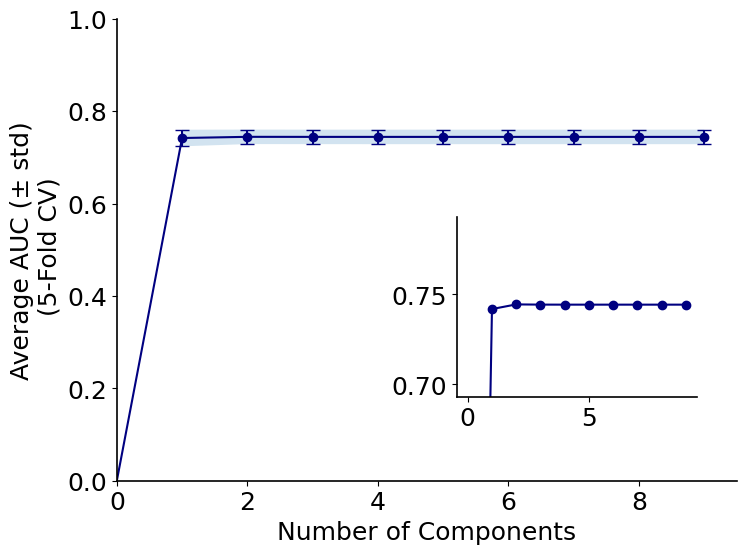

Maximum AUC at components: 2
Diminishing returns at components: 1
Maximum mean AUC: 0.744 ± 0.016
AUC at diminishing returns: 0.742 ± 0.018
Recommended number of components: 1
Optimal number of components: 1
Component 1:
Cumulative Y variance: 14.02%
Incremental Y variance: 14.02%
Component 2:
Cumulative Y variance: 14.15%
Incremental Y variance: 0.12%


/Users/njr7jk/opt/anaconda3/envs/ap1_proj/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/njr7jk/opt/anaconda3/envs/ap1_proj/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/njr7jk/opt/anaconda3/envs/ap1_proj/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/njr7jk/opt/anaconda3/envs/ap1_proj/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_in

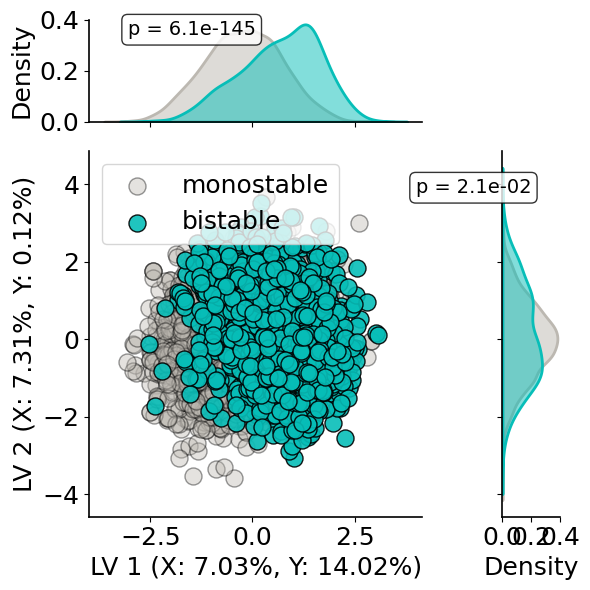

In [44]:
plsda = PLSDA(n_components=None, cv_folds=5, one_hot_encode=False, downsample_ratio=3)

# Limit the search range safely
max_k = min(9, X.shape[1], max(1, X.shape[0]-1))
optimal_components, mean_scores = plsda.find_optimal_components(X, y, max_components=max_k, save_plot=False)
print(f'Optimal number of components: {optimal_components}')

# If you want a 2D plot, fit at least 2 components; otherwise just use optimal
plsda.n_components = 2

X_pls, x_var, y_var, y_encoded, X_downsampled, y_balanced = plsda.fit_transform(X, y)

others_label = "monostable"
interest_label = "bistable"  # Convert list to string
class_descriptions = {0: others_label, 1: interest_label}
# color for mono_stable is #BCB8B1 and bistable is #07BEB8
plot_scores = plsda.plot_scores_with_density(
    X_pls, x_var, y_var, y_encoded, lv1=0, lv2=1,
    class_descriptions=class_descriptions,
    alpha_values=[0.4, 0.9],
    colors=['#BCB8B1', '#07BEB8'],
    line_colors=['k', 'k'],
    save_plot=True, size=[150, 150]
)

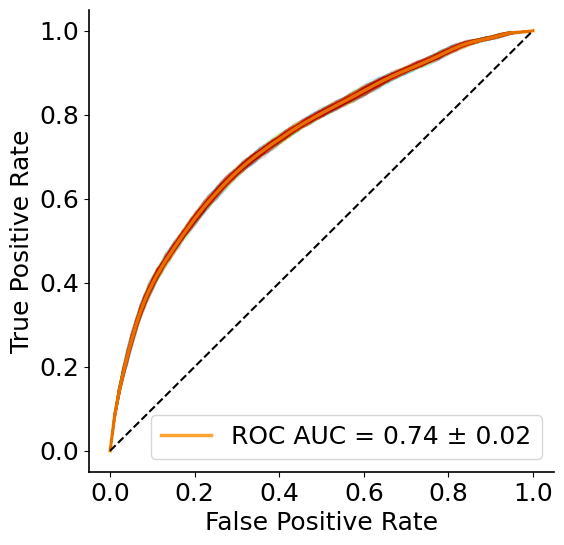

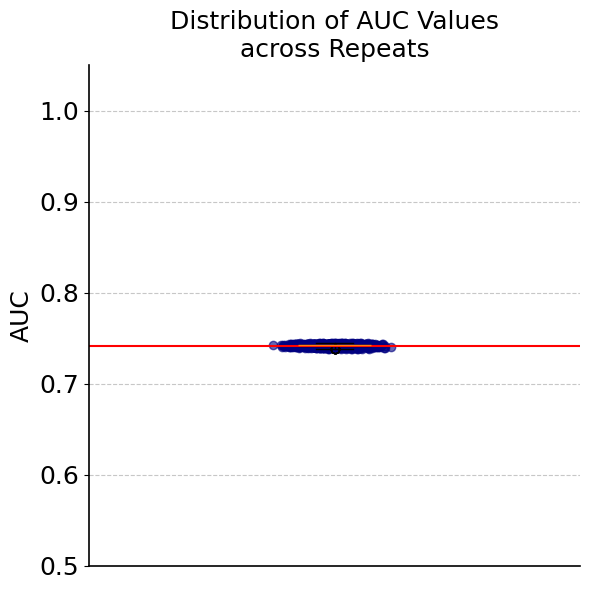

Repeated CV Results (1000 repeats):
Mean AUC: 0.742 ± 0.001
Range: [0.738, 0.745]
Repeated cross-validation AUC: 0.742 ± 0.001


In [45]:
mean_auc, std_auc = plsda.repeated_cv_with_visualization(
    X, y, n_repeats=1000, save_plot=True, show_individual_curves=True 
)
print(f"Repeated cross-validation AUC: {mean_auc:.3f} ± {std_auc:.3f}")

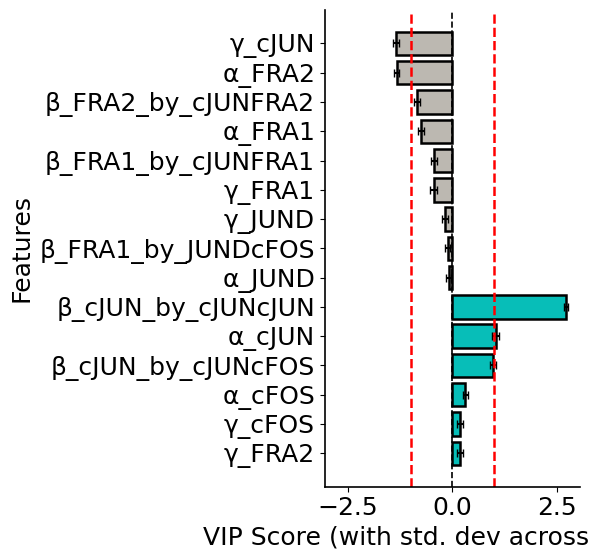

In [46]:
# VIP from repeated down sampling and cross validation
mean_vips, std_vips, feature_names = plsda.plot_repeated_vip(
    X, y, n_repeats=1000,colors=['#BCB8B1', '#07BEB8'],save_plot=True
)